# Imports

In [2]:
import os
import config
os.environ["OPENAI_API_KEY"] = config.OPENAI_API_KEY
os.environ["OPENAI_API_BASE"] = config.OPENAI_API_BASE

In [83]:
from PIL import Image
from sentence_transformers import SentenceTransformer
from transformers import CLIPProcessor, CLIPModel
from torchvision import transforms
import torch
import chromadb
from langchain_chroma import Chroma
from langchain.chat_models import ChatOpenAI
from langchain.chains import RetrievalQA
from langchain.embeddings.base import Embeddings
from typing import List
import pandas as pd
import json
from langchain.prompts import PromptTemplate
import matplotlib.pyplot as plt

# Load Text Data

In [12]:
df = pd.read_csv('dummy_housing_data_v2.csv', index_col=0).drop(['id'], axis=1)
df.head()

,neighborhood_name,price,bedrooms,bathrooms,house_size,year_built,description,neighborhood_description
0,Willow Creek,650000,4,3.5,3000,2005,Discover the perfect family home in the desira...,Willow Creek is known for its top-rated school...
1,Riverfront Estates,950000,5,4.0,5000,2010,Luxury living awaits in the prestigious Riverf...,"Riverfront Estates offers waterfront views, pr..."
2,Sunny Hills,400000,3,2.5,1800,1998,Welcome home to the charming neighborhood of S...,Sunny Hills is a family-friendly community wit...
3,Oak Ridge,750000,4,3.0,2800,2008,Live the ultimate suburban lifestyle in the so...,"Oak Ridge boasts tree-lined streets, community..."
4,Maple Grove,550000,3,2.5,2400,2000,Step into this meticulously maintained home in...,"Maple Grove offers tree-lined streets, communi..."


In [45]:
def create_query_text(row):
    query = f"""
    House with {row['bedrooms']} bedrooms and {row['bathrooms']} built in {row['year_built']}.
    The house has {row['house_size']} sqft and costs {row['price']} USD.
    {row['description']}
    The neighborhood {row['neighborhood_name']}: {row['neighborhood_description']}
    """
    return query

def create_metadata(row):
    return row[['price','bedrooms','bathrooms','house_size','year_built','neighborhood_name']].to_dict()

# Create Embeddings

In [24]:
# Load CLIP model (same for text and images)
clip_model = SentenceTransformer("clip-ViT-B-32")

# Helper to embed text
def embed_text(text: str) -> List[float]:
    return clip_model.encode(text, convert_to_tensor=True).cpu().tolist()

In [25]:
# Load huggingface CLIP for image embedding
hf_clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
hf_clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def embed_image(image_path: str) -> List[float]:
    image = Image.open(image_path).convert("RGB")
    inputs = hf_clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = hf_clip_model.get_image_features(**inputs)
    return outputs[0].cpu().numpy().tolist()

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [26]:
# Wrapper to allow CLIP as LangChain-compatible embedding function
class CLIPEmbedding(Embeddings):
    def embed_query(self, text: str) -> List[float]:
        return embed_text(text)

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return [embed_text(t) for t in texts]

In [27]:
def create_embeddings(user_text: str, image_path: str = None):
    query_embedding = embed_text(user_text)
    
    if image_path and os.path.exists(image_path):
        image_embedding = embed_image(image_path)
        # Average embeddings (simple way to combine)
        query_embedding = [
            (t + i) / 2 for t, i in zip(query_embedding, image_embedding)
        ]

    return query_embedding

def add_listing_to_db(text: str, image_path: str, metadata: dict):
    combined_emb = create_embeddings(text, image_path)

    vectordb.add_texts(
        texts=[text],
        metadatas=[metadata],
        embeddings=[combined_emb]
    )

In [87]:
# Add data to Chroma DB
embedding_function = CLIPEmbedding()

vectordb = Chroma(
    collection_name="real_estate_multimodal",
    embedding_function=embedding_function
)

for i, row in df.iterrows():
    text_query = create_query_text(row)
    metadata = create_metadata(row)
    metadata['id'] = i
    image_path = f'./images/image_{i}.png'
    add_listing_to_db(text_query, image_path, metadata)

In [88]:
len(vectordb.get()['ids'])
#vectordb.delete_collection()

10

# Query Vector DB

## Load Q&A Results

In [59]:
with open('qa_data.json', 'r') as file:
     qa_data = json.load(file)
print(qa_data)

{'questions': ['How many bed- and bathrooms do you want?', 'How many square feet?', 'How old can the house be?', 'What are the 3 most important things in the house?', 'Are there any amenities you want?', 'What kind of neighborhood do you want to live in?', 'How urban do you want your neighborhood to be?'], 'customer1': ['I want a three-bedroom, two-bathroom house.', 'Between 2000 to 3000 sqft.', 'I think it should be built in 1985 or later.', 'A spacious kitchen, a cozy living room, big windows.', 'A backyard for gardening, a two-car garage, and a modern, energy-efficient heating system.', 'A quiet neighborhood with good local schools, and convenient shopping options and easy access to major highways.', 'A balance between suburban tranquility and access to urban amenities like restaurants and theaters.'], 'customer2': ['A luxurious 5-bedroom, 3-bathroom house.', '5000 sqft or more.', 'Relatively new, built 2000 or later.', 'A gourmet kitchen, a winter garden, high ceilings.', 'A big ga

## Turn QA to Query

In [60]:
model_name = "gpt-3.5-turbo"
temperature = 0.3
llm = ChatOpenAI(model_name=model_name, temperature=temperature)

query_prompt = PromptTemplate(
    input_variables=["user_input"],
    template="""
    Extract a house description from the user chat history following below. 
    Make sure to include amenities, year built preferences and house size (bedrooms, bathrooms, sqft) 
    in the description. Keep it simple, maximum 2 sentences.

    ************User chat history:**************
     "{user_input}"
    """
)

def create_qa(questions, answers):
    qa = ""
    for i in range(len(questions)):
        qa += "Q: " + questions[i] + "\nA: " + answers[i] + "\n"

    return qa

qa_prompts = {}
for i, key in enumerate(['customer1', 'customer2', 'customer3']):
    user_input = create_qa(qa_data['questions'], qa_data[key])
    print(user_input)
    query = llm.invoke(query_prompt.format(user_input=user_input)).content
    print(query)
    print("")
    qa_prompts[i+1] = query

Q: How many bed- and bathrooms do you want?
A: I want a three-bedroom, two-bathroom house.
Q: How many square feet?
A: Between 2000 to 3000 sqft.
Q: How old can the house be?
A: I think it should be built in 1985 or later.
Q: What are the 3 most important things in the house?
A: A spacious kitchen, a cozy living room, big windows.
Q: Are there any amenities you want?
A: A backyard for gardening, a two-car garage, and a modern, energy-efficient heating system.
Q: What kind of neighborhood do you want to live in?
A: A quiet neighborhood with good local schools, and convenient shopping options and easy access to major highways.
Q: How urban do you want your neighborhood to be?
A: A balance between suburban tranquility and access to urban amenities like restaurants and theaters.

I am looking for a three-bedroom, two-bathroom house built in 1985 or later with a spacious kitchen, cozy living room, big windows, a backyard for gardening, a two-car garage, and a modern, energy-efficient heatin

In [61]:
qa_prompts

{1: 'I am looking for a three-bedroom, two-bathroom house built in 1985 or later with a spacious kitchen, cozy living room, big windows, a backyard for gardening, a two-car garage, and a modern, energy-efficient heating system. The house should be between 2000 to 3000 sqft in size.',
 2: 'Looking for a luxurious 5-bedroom, 3-bathroom house with over 5000 sqft, built in 2000 or later. Amenities include a big garden, pool, and a renovated or fairly new house.',
 3: 'The ideal house would be a spacious 4-bedroom, 2-bathroom home with over 4000 sqft, featuring a very open kitchen and good views from the windows. It should also have a gigantic garden for animals, many trees on the property, and be located in a private and quiet countryside neighborhood with access to surrounding nature and hiking trails.'}

## Find similar listings

In [103]:
# Custom function to query by multimodal input
def retrieve_similar_listings(user_text: str, image_path: str = None, top_k: int = 3):
    query_embedding = embed_text(user_text)

    if image_path and os.path.exists(image_path):
        image_embedding = embed_image(image_path)
        # Average embeddings (simple way to combine)
        query_embedding = [
            (t + i) / 2 for t, i in zip(query_embedding, image_embedding)
        ]

    results = vectordb.similarity_search_by_vector(query_embedding, k=top_k)
    #results = vectordb.similarity_search_by_vector_with_relevance_scores(query_embedding, k=top_k)
    return results

In [104]:
db_results = {}
for key, text in qa_prompts.items():
    image_path = f'./images_qa/image_{i}.png'
    db_results[key] = retrieve_similar_listings(text, image_path)

In [105]:
db_results

{1: [(Document(id='13a28e74-01eb-4cce-aa95-08d76041f0b1', metadata={'bathrooms': 3.0, 'bedrooms': 4, 'house_size': 3200, 'id': 6, 'neighborhood_name': 'Meadowbrook Ridge', 'price': 850000, 'year_built': 2015}, page_content='\n    House with 4 bedrooms and 3.0 built in 2015.\n    The house has 3200 sqft and costs 850000 USD.\n    Indulge in luxury living in the upscale Meadowbrook Ridge neighborhood. This stunning 4-bedroom, 3-bathroom home features high-end finishes, a gourmet kitchen with top-of-the-line appliances, and a private backyard retreat with a custom pool and spa. The sprawling master suite offers a peaceful haven to escape the daily hustle and bustle.\n    The neighborhood Meadowbrook Ridge: Meadowbrook Ridge is an exclusive community known for its grand estates, lush landscaping, and picturesque views. Residents enjoy access to private walking trails, tennis courts, and a country club for social gatherings and events.\n    '),
   45.43145751953125),
  (Document(id='987765a

# Final Result Augmentation

In [82]:
# Prepare prompt template
augment_prompt = PromptTemplate(
    input_variables=["listings", "preferences"],
    template="""
        You are a real estate agent. 
        A customer is looking for a house and gave you the following preference information:
        
        {preferences}
        
        Based on the preferences, a housing database gave you the top 3 housing listings currently available:
        
        {listings}

        Instructions:
        Rewrite the description of each housing listing to fit the preferences of the customer. 
        Do not add anything that is not in the description.
        Make it sound appealing, engaging, and personalized. 
        Directly speak to the customer and point out in a structured manner how the house aligns with the customers mentioned preferences.
        Then, add another section that compares the three houses which each other in a structured way to make them more comparable.
        """
        )

In [71]:
# Define LLM model
model_name = "gpt-3.5-turbo"
temperature = 0.3
llm = ChatOpenAI(model_name=model_name, temperature=temperature)

In [99]:
def retrieve_listings(query_results):
    listings = ""
    for result in query_results:
        listings += result.page_content + "\n"
    return listings

def plot_images(images, image_titles):
    # Create a row of 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for ax, img, title in zip(axes, images, image_titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")  # Hide axes
    
    plt.tight_layout()
    plt.show()

def retrieve_images(ix, db_results):
    qa_image_path = f"./images_qa/image_{ix}.png"
    db_image_path = [f"./images/image_{entry.metadata['id']}.png" for entry in db_results]
    db_image_path.append(qa_image_path)
    image_titles = [f"Image for House {entry.metadata['id']}" for entry in db_results]
    image_titles.append("Customer Dream House Image")

    images = [Image.open(path) for path in db_image_path]

    return images, image_titles

**********************************Customer 1****************************************

        You are a real estate agent. 
        A customer is looking for a house and gave you the following preference information:

        I am looking for a three-bedroom, two-bathroom house built in 1985 or later with a spacious kitchen, cozy living room, big windows, a backyard for gardening, a two-car garage, and a modern, energy-efficient heating system. The house should be between 2000 to 3000 sqft in size.

        Based on the preferences, a housing database gave you the top 3 housing listings currently available:

        
    House with 4 bedrooms and 3.0 built in 2015.
    The house has 3200 sqft and costs 850000 USD.
    Indulge in luxury living in the upscale Meadowbrook Ridge neighborhood. This stunning 4-bedroom, 3-bathroom home features high-end finishes, a gourmet kitchen with top-of-the-line appliances, and a private backyard retreat with a custom pool and spa. The sprawling master 

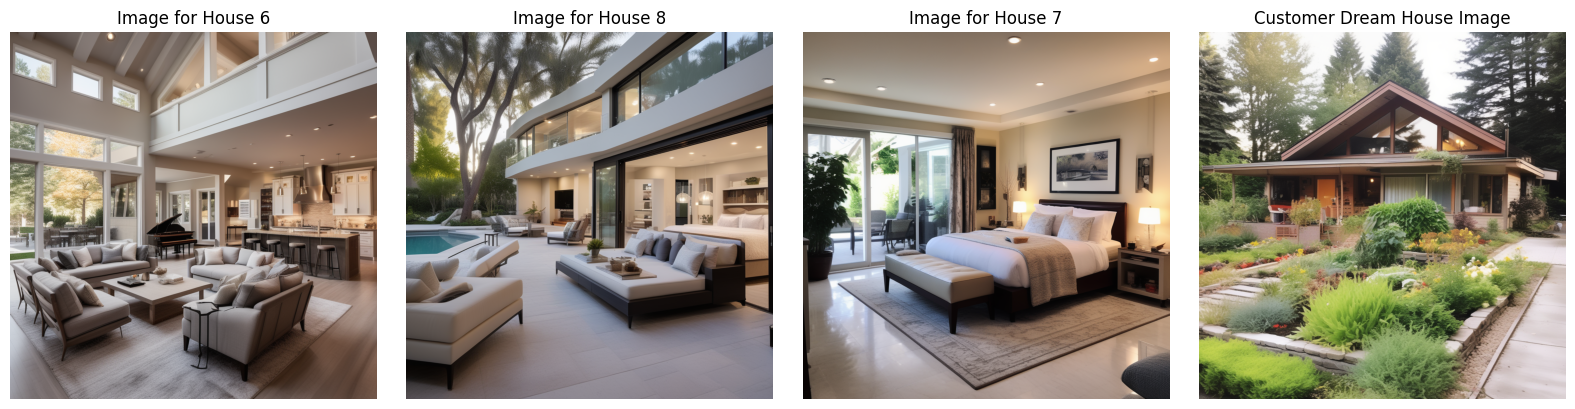

**********************************Customer 2****************************************

        You are a real estate agent. 
        A customer is looking for a house and gave you the following preference information:

        Looking for a luxurious 5-bedroom, 3-bathroom house with over 5000 sqft, built in 2000 or later. Amenities include a big garden, pool, and a renovated or fairly new house.

        Based on the preferences, a housing database gave you the top 3 housing listings currently available:

        
    House with 4 bedrooms and 3.0 built in 2015.
    The house has 3200 sqft and costs 850000 USD.
    Indulge in luxury living in the upscale Meadowbrook Ridge neighborhood. This stunning 4-bedroom, 3-bathroom home features high-end finishes, a gourmet kitchen with top-of-the-line appliances, and a private backyard retreat with a custom pool and spa. The sprawling master suite offers a peaceful haven to escape the daily hustle and bustle.
    The neighborhood Meadowbrook Ridg

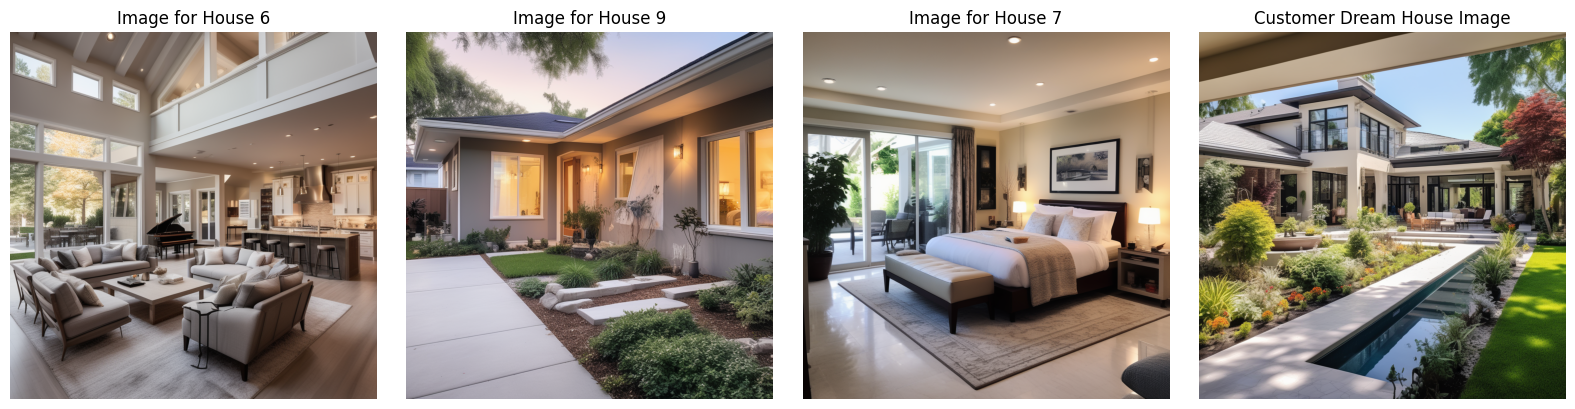

**********************************Customer 3****************************************

        You are a real estate agent. 
        A customer is looking for a house and gave you the following preference information:

        The ideal house would be a spacious 4-bedroom, 2-bathroom home with over 4000 sqft, featuring a very open kitchen and good views from the windows. It should also have a gigantic garden for animals, many trees on the property, and be located in a private and quiet countryside neighborhood with access to surrounding nature and hiking trails.

        Based on the preferences, a housing database gave you the top 3 housing listings currently available:

        
    House with 3 bedrooms and 2.0 built in 2003.
    The house has 2200 sqft and costs 500000 USD.
    Welcome to the tranquil neighborhood of Cedar Grove. This 3-bedroom, 2-bathroom home offers a comfortable and inviting space to call your own. The open floor plan is perfect for modern living, while the backy

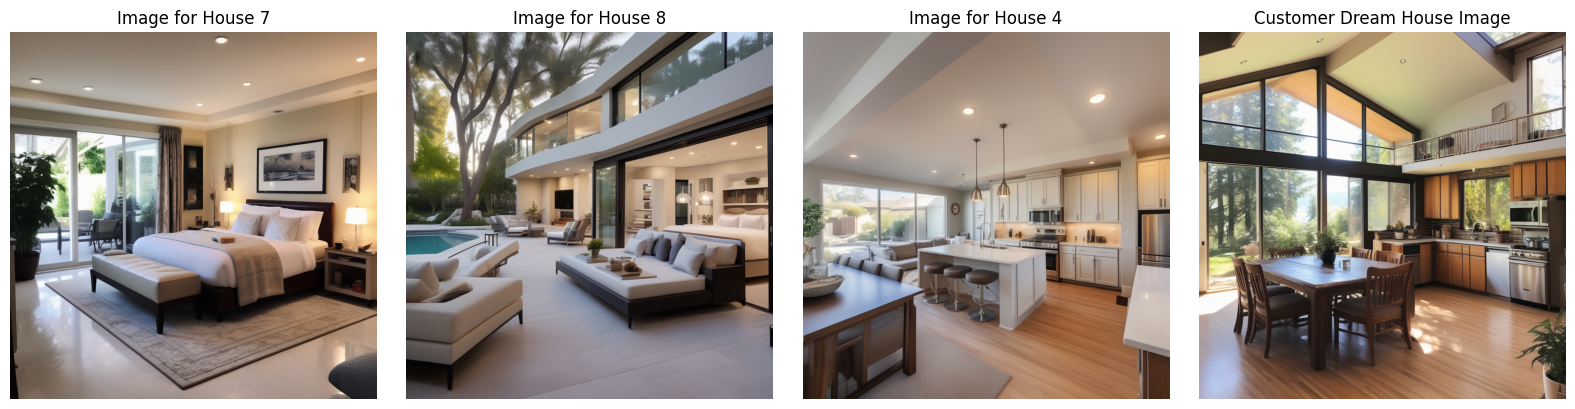

In [100]:
for key in db_results.keys():
    print(f"**********************************Customer {key}****************************************")
    query = qa_prompts[key]
    listing_results = retrieve_listings(db_results[key])

    prompt = augment_prompt.format(preferences=query, listings=listing_results)
    print(prompt)

    print("************************")

    response = llm.invoke(prompt)
    print(response.content)

    print("************************")

    images, image_titles = retrieve_images(key, db_results[key])
    plot_images(images, image_titles)